# 《Cookie Cats》门禁位置 A/B 实验 — 探索分析

**数据**：Tactile Entertainment 三消手游 Cookie Cats 的线上随机对照实验（真实数据，
[Kaggle 公开数据集](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats)）。

**实验**：关卡门禁从第 30 关后移到第 40 关。`gate_30` 对照组 vs `gate_40` 实验组，
观察窗为安装后 14 天，共 90,189 名玩家。

**字段**：`userid` 玩家，`version` 分组，`sum_gamerounds` 14 天内总游玩局数，
`retention_1` 次日是否回流，`retention_7` 第 7 天是否回流。

> 结论速览：门禁后移使 **7 日留存显著下降 0.82pp（p=0.0016）**，
> 次日留存方向为负但不显著；游玩局数差异被极端账号主导、不稳健。
> 建议门禁维持在 30 关，并把收入指标纳入后续实验。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # 允许从 src 导入

import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import config as C
from src import data as datalib
from src import ab_test as ab
from src import charts

pd.set_option("display.width", 120)
charts.apply_style()
df, rule = datalib.prepare()
df.shape

(90189, 9)

## 1. 数据理解与质量审计

先看字段、分布、缺失与主键重复。

In [2]:
display(df.head())
display(df.dtypes)
print("缺失值:\n", df[['userid','version','sum_gamerounds','retention_1','retention_7']].isna().sum())
print("userid 重复数:", df['userid'].duplicated().sum())
print("分组取值:", df['version'].value_counts().to_dict())
print("局数为负:", (df['sum_gamerounds'] < 0).sum())

,userid,version,sum_gamerounds,retention_1,retention_7,tier,funnel_install,funnel_d1,funnel_d7
0,116,gate_30,3,0,0,轻度玩家,1,0,0
1,337,gate_30,38,1,0,中度玩家,1,1,0
2,377,gate_40,165,1,0,重度玩家,1,1,0
3,483,gate_40,1,0,0,轻度玩家,1,0,0
4,488,gate_40,179,1,1,重度玩家,1,1,1


userid             int64
version           object
sum_gamerounds     int64
retention_1         int8
retention_7         int8
tier              object
funnel_install     int64
funnel_d1           int8
funnel_d7           int8
dtype: object

缺失值:
 userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64
userid 重复数: 0
分组取值: {'gate_40': 45489, 'gate_30': 44700}
局数为负: 0


In [3]:
# SRM：样本比例失衡检验（实验可信度的第一道闸门）
srm = ab.srm_test(df)
pd.Series(srm)

n_control            44700
n_treatment          45489
expected_ratio         0.5
observed_ratio    0.495626
diff_pp           0.437415
chi2              6.902405
p_value           0.008608
is_srm               False
warning               True
dtype: object

**SRM 判读**：分流比 49.56% / 50.44%，卡方 p=0.009 触发统计预警，
但实际偏差仅 0.44pp（<1pp 业务阈值）。9 万样本下分流哈希的轻微抖动也会被检出，
本项目采用 p<0.005 或偏差>1pp 的**双门槛**，未达阻断线；
且分流发生在安装时刻、统计口径是全量玩家，选择性流失无法解释该偏差。

## 2. 大盘画像：留存漏斗与参与度集中度

In [4]:
summary = ab.group_summary(df)
summary.T

group,gate_30,gate_40
n_users,44700.000000,45489.000000
share_pct,49.562585,50.437415
zero_round_pct,4.333333,4.521972
rounds_mean,52.456264,51.298776
rounds_median,17.000000,16.000000
rounds_p90,135.000000,134.000000
rounds_p99,493.000000,492.120000
rounds_max,49854.000000,2640.000000
retention_1_pct,44.818792,44.228275
retention_7_pct,19.020134,18.200004


In [5]:
display(ab.funnel(df))
tier_sizes = ab.tier_sizes(df)
display(tier_sizes)
lorenz, gini = ab.rounds_concentration(df)
print("游玩局数 Gini =", round(gini, 3))

,group,stage,n,pct_of_install
0,gate_30,安装,44700,100.000000
1,gate_30,次日留存,20034,44.818792
2,gate_30,7日留存,8502,19.020134
3,gate_40,安装,45489,100.000000
4,gate_40,次日留存,20119,44.228275
5,gate_40,7日留存,8279,18.200004


,tier,n,total_rounds,n_pct,rounds_pct
0,安装未玩,3994,0,4.428478,0.000000
1,轻度玩家,43617,309553,48.361774,6.616749
2,中度玩家,34021,1819679,37.721895,38.895951
3,重度玩家,7697,1865598,8.534300,39.877478
4,超核玩家,860,683495,0.953553,14.609823


游玩局数 Gini = 0.709


- 次日留存 ~44%、7 日留存 ~19%，三消手游典型的早期陡降；
- **4.4% 的玩家安装后一局未玩**；1% 的超核玩家贡献 14.6% 的局数，Gini=0.709，
  参与度高度集中——留存运营面向全体新手，资源分配要接受头部集中现实。

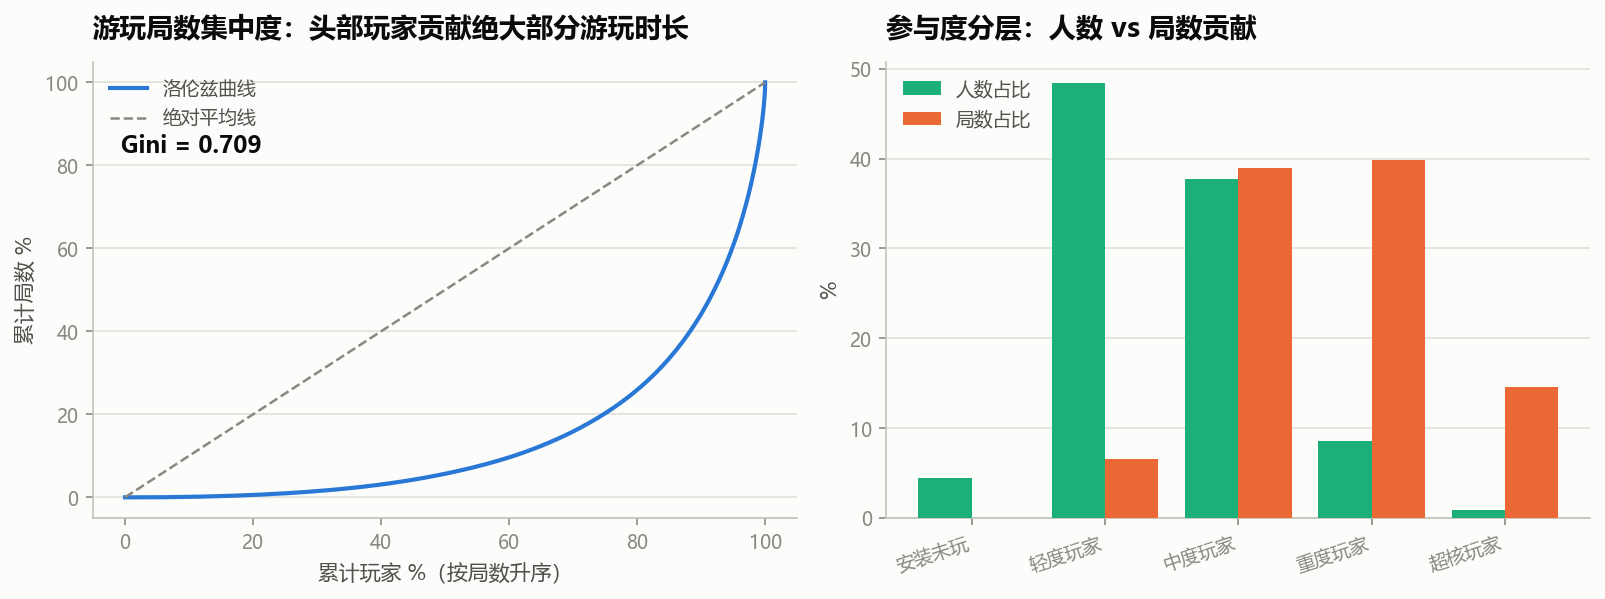

In [6]:
Image(filename=str(C.FIG_DIR / '08_concentration.png'))

## 3. 核心推断：门禁后移对留存的影响

In [7]:
results = {}
for col, name in [('retention_1', '次日留存'), ('retention_7', '7日留存')]:
    n_c = (df.version == C.CONTROL).sum()
    n_t = (df.version == C.TREATMENT).sum()
    s_c = df.loc[df.version == C.CONTROL, col].sum()
    s_t = df.loc[df.version == C.TREATMENT, col].sum()
    results[name] = ab.two_proportion_test(s_c, n_c, s_t, n_t)
pd.DataFrame(results).T

,rate_control,rate_treatment,diff_pp,relative_lift_pct,ci_low_pp,ci_high_pp,z,p_value
次日留存,0.448188,0.442283,-0.590517,-1.317566,-1.239244,0.058210,-1.784086,0.074410
7日留存,0.190201,0.182000,-0.820130,-4.311903,-1.328155,-0.312104,-3.164359,0.001554


- 次日留存：44.82% → 44.23%，Δ=-0.59pp，p=0.074，**不显著但方向为负**；
- 7 日留存：19.02% → 18.20%，Δ=-0.82pp，p=0.0016，**显著为负**，相对降幅 4.3%。

### 3.1 Bootstrap（非参数，10,000 次）

In [8]:
for col, name in [('retention_1', '次日留存'), ('retention_7', '7日留存')]:
    b = ab.bootstrap_rate(df, col, n_boot=10_000)
    print(name, f"95% CI [{b['ci_low_pp']:+.2f}, {b['ci_high_pp']:+.2f}] pp,",
          f"P(实验组更低) = {b['p_treatment_lower']:.1%}")

次日留存 95% CI [-1.24, +0.06] pp, P(实验组更低) = 96.3%
7日留存 95% CI [-1.33, -0.31] pp, P(实验组更低) = 99.9%


### 3.2 贝叶斯：Jeffreys 先验 Beta(½,½)

次日留存 95% CrI [-1.24, +0.06] pp, 后验 P(实验组更低) = 96.3%


7日留存 95% CrI [-1.33, -0.31] pp, 后验 P(实验组更低) = 99.9%


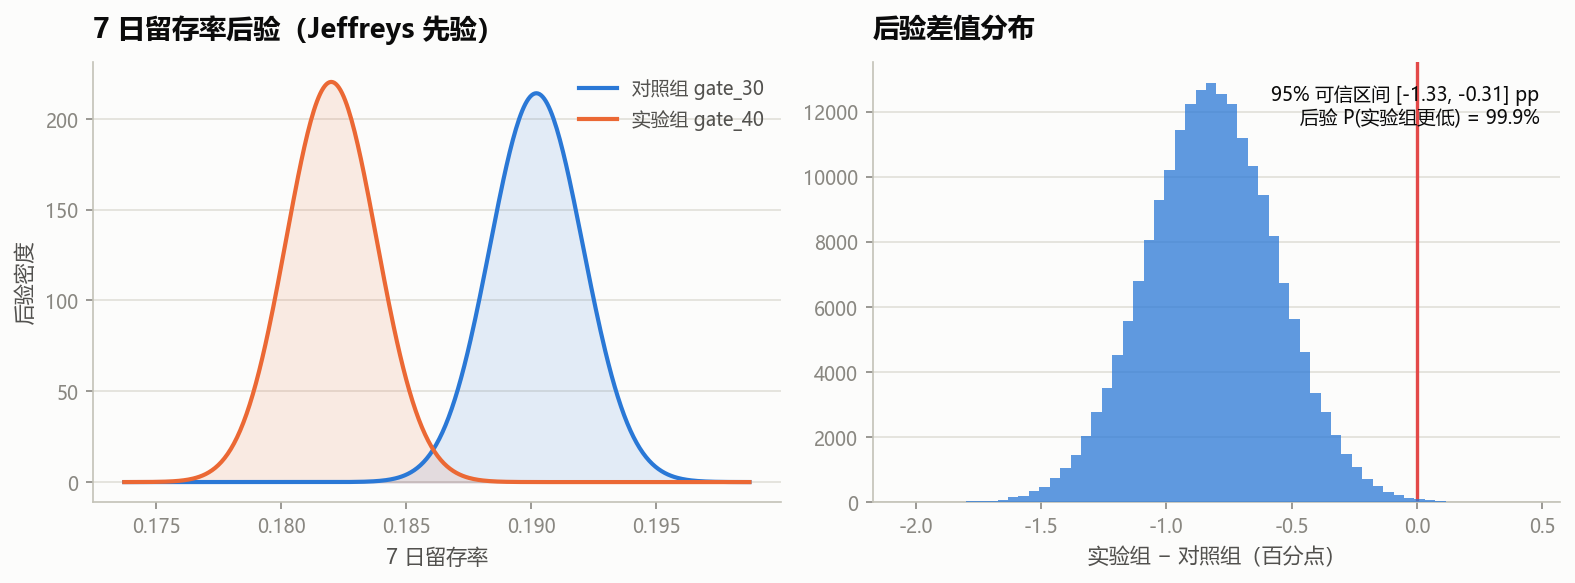

In [9]:
for col, name in [('retention_1', '次日留存'), ('retention_7', '7日留存')]:
    y = ab.bayes_retention(df, col, n_mc=200_000)
    print(name, f"95% CrI [{y['ci_low_pp']:+.2f}, {y['ci_high_pp']:+.2f}] pp,",
          f"后验 P(实验组更低) = {y['p_treatment_lower']:.1%}")
Image(filename=str(C.FIG_DIR / '06_bayes_posterior.png'))

**三套方法（z 检验 / bootstrap / 贝叶斯）结论一致**：
D7 受损证据充分（频率派 p=0.0016，95% 区间不含 0，后验概率 99.9%）；
D1 方向一致但证据不足。

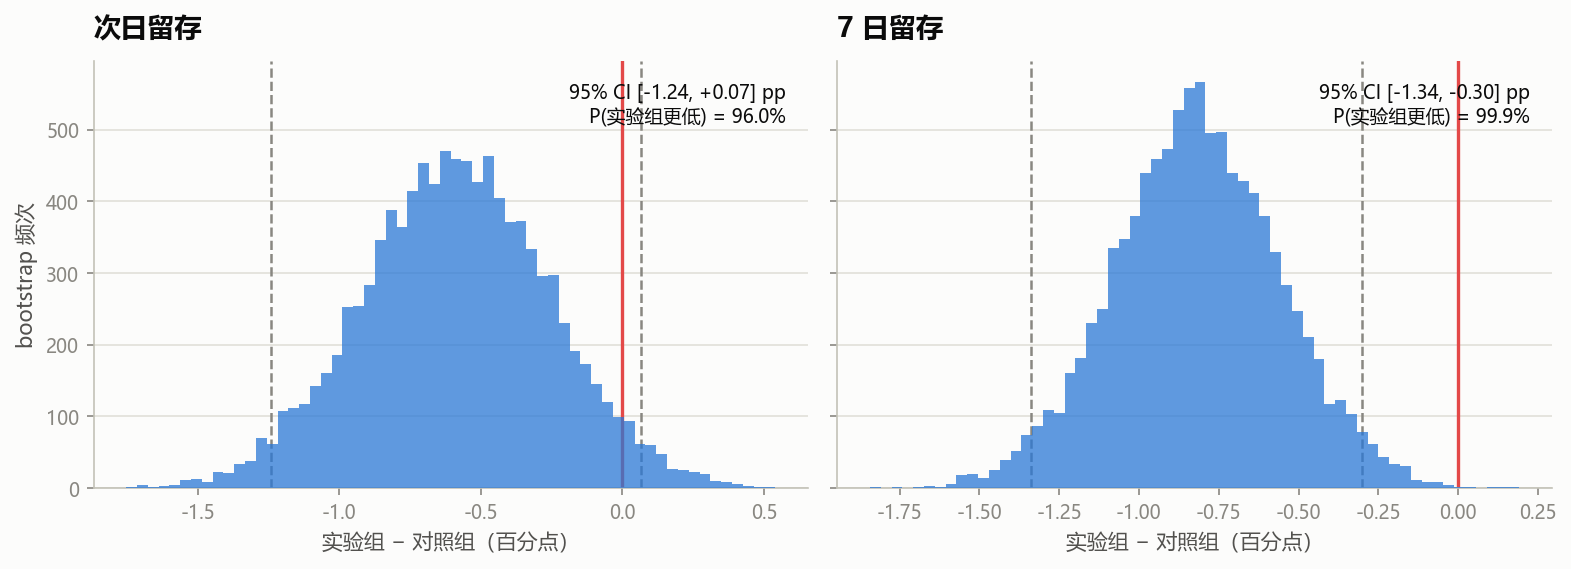

In [10]:
Image(filename=str(C.FIG_DIR / '03_bootstrap_retention.png'))

## 4. 护栏指标：游玩局数与极端值敏感性

In [11]:
mwu = ab.mannwhitney_rounds(df)
print('Mann-Whitney U p =', round(mwu['p_value'], 4),
      ' rank-biserial r =', round(mwu['rank_biserial'], 4))
full = ab.bootstrap_rounds(df, n_boot=2000)
trim = ab.bootstrap_rounds(df, n_boot=2000, cutoff=int(rule.outlier_cut))
print(f"全量: 均值差 CI [{full['ci_low']:+.2f}, {full['ci_high']:+.2f}],"
      f" P(更低)={full['p_treatment_lower']:.1%}")
n_excl = int((df.sum_gamerounds > rule.outlier_cut).sum())
print(f"剔除 {n_excl} 名 >{int(rule.outlier_cut)} 局玩家: "
      f"CI [{trim['ci_low']:+.2f}, {trim['ci_high']:+.2f}], P(更低)={trim['p_treatment_lower']:.1%}")
print("最大局数:", df['sum_gamerounds'].max())

Mann-Whitney U p = 0.0502  rank-biserial r = -0.0075


全量: 均值差 CI [-4.17, +0.96], P(更低)=79.2%
剔除 91 名 >1073 局玩家: CI [-1.48, +0.90], P(更低)=66.1%
最大局数: 49854


局数分布极度重尾，单个玩家玩了 49,854 局（疑似脚本/测试号）。
全量时均值差 bootstrap 的 P(更低)=80%，剔除 91 名极端玩家后降到 68%——
**结论被少数账号支配，不能作为决策依据**；MWU 效应量 r 仅 -0.0075，无业务意义。
决策以留存指标为准。

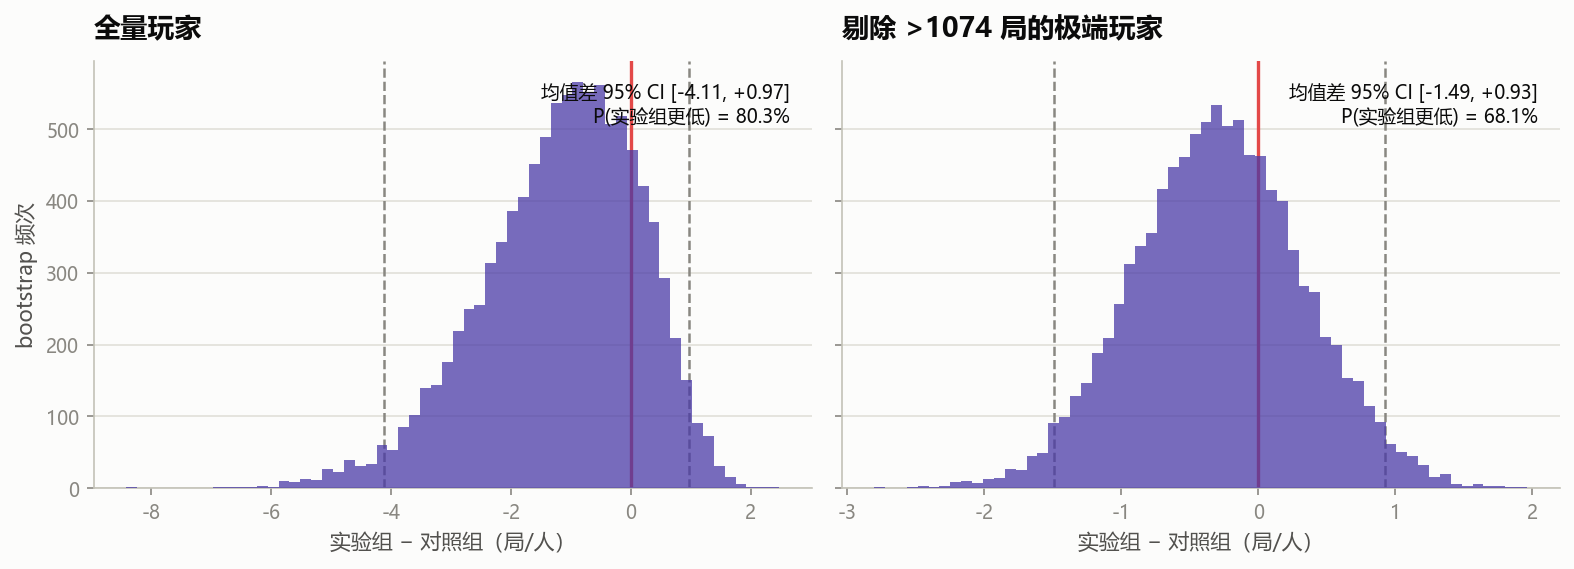

In [12]:
Image(filename=str(C.FIG_DIR / '05_rounds_sensitivity.png'))

## 5. 分层观察（处理后变量，仅描述）

参与度是实验的处理后变量，分层内差异不能做因果解释，只看负效应是否集中。

n          retention_1            retention_7           
version  gate_30  gate_40     gate_30    gate_40     gate_30    gate_40
tier                                                                   
中度玩家     17036.0  16985.0   70.351021  70.256108   26.379432  25.027966
安装未玩      1937.0   2057.0    2.116675   2.236266    0.826020   0.631988
超核玩家       428.0    432.0   97.196262  97.685185   94.859813  96.296296
轻度玩家     21467.0  22150.0   19.047841  18.925508    3.051195   2.930023
重度玩家      3832.0   3865.0   91.414405  91.228978   76.487474  76.326003

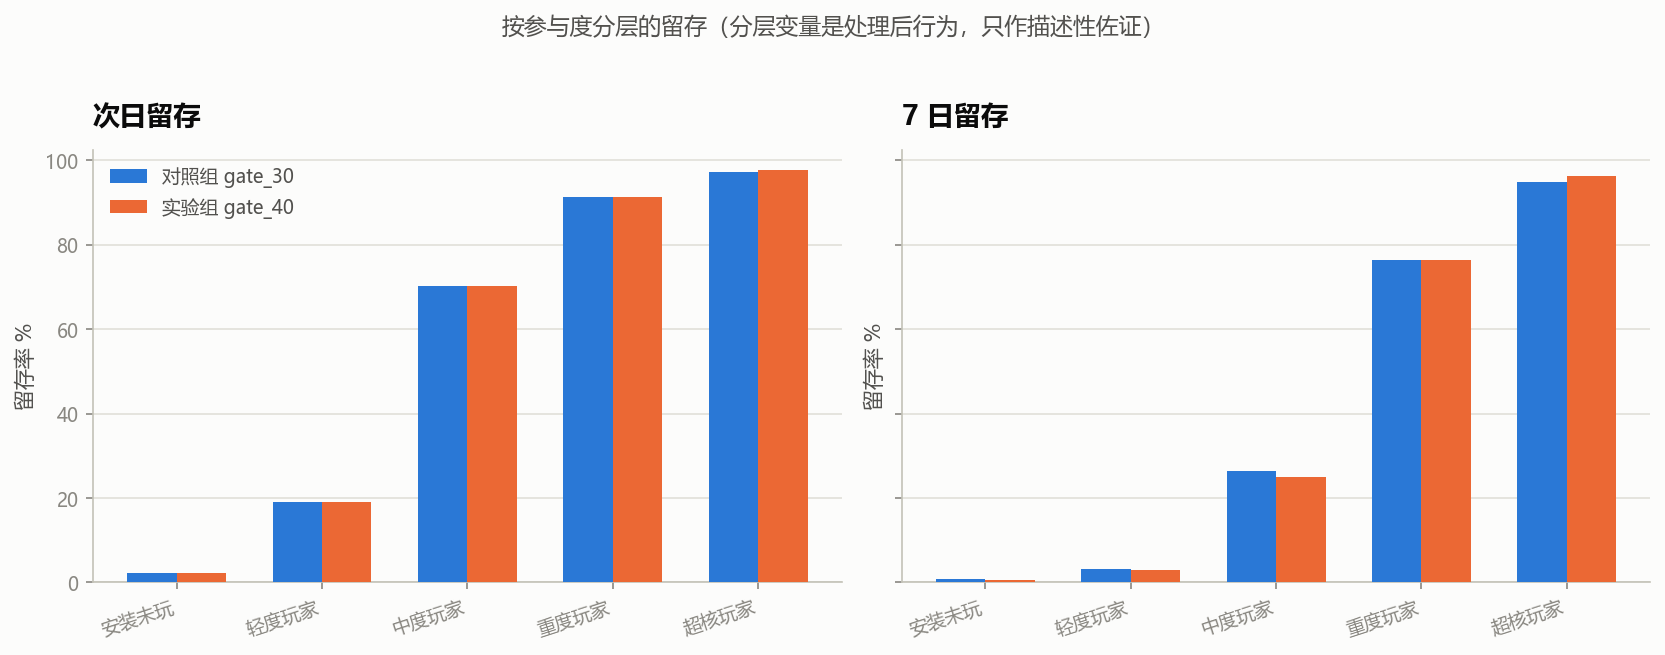

In [13]:
tier_df = ab.tier_table(df)
display(tier_df.pivot(index='tier', columns='version',
                      values=['n','retention_1','retention_7']))
Image(filename=str(C.FIG_DIR / '07_tier_retention.png'))

## 6. 实验灵敏度复盘

当前单组 44,700 人，可检出 MDE ≈ 0.74pp（α=5%, power=80%）
检出 0.5pp 需单组 9.8 万人
检出 0.3pp 需单组 27.0 万人


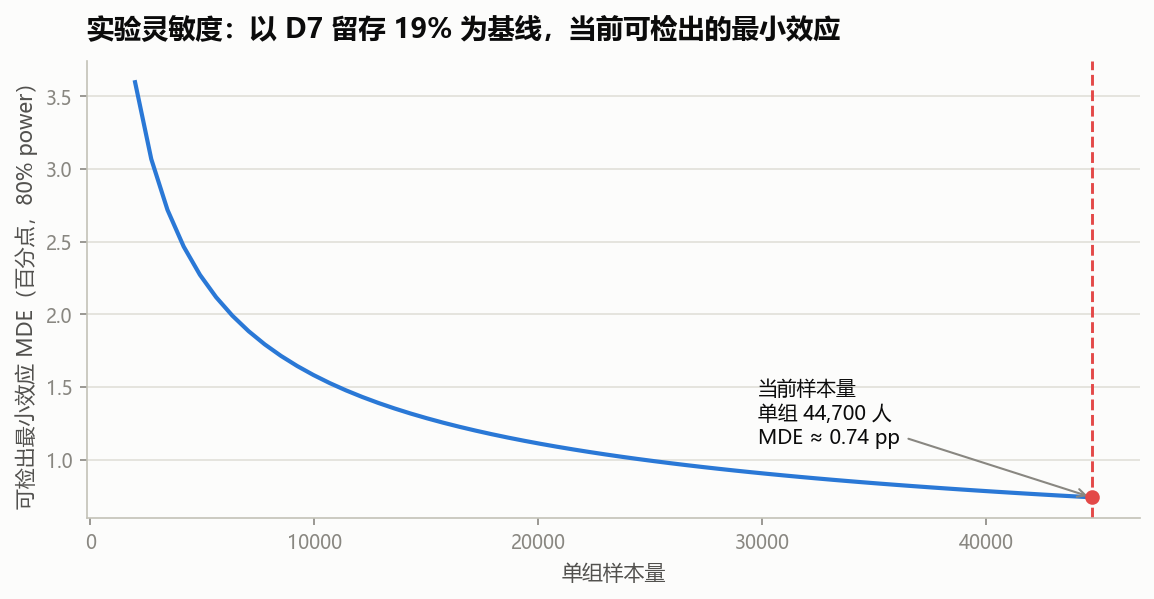

In [14]:
n_per_arm = int(summary['n_users'].min())
p_base = results['7日留存']['rate_control']
curve = ab.mde_curve(p_base, n_per_arm)
mde_now = curve['mde_pp'].iloc[-1]
print(f"当前单组 {n_per_arm:,} 人，可检出 MDE ≈ {mde_now:.2f}pp（α=5%, power=80%）")
print("检出 0.5pp 需单组", f"{ab.required_n_per_arm(p_base, 0.5)/1e4:.1f} 万人")
print("检出 0.3pp 需单组", f"{ab.required_n_per_arm(p_base, 0.3)/1e4:.1f} 万人")
Image(filename=str(C.FIG_DIR / '09_power_mde.png'))

## 7. 结论与业务建议

1. **门禁维持在第 30 关（回滚 gate_40）**：后移使 7 日留存显著下降 0.82pp（相对 4.3%），
   折合每 10 万新增在观察窗内多流失约 820 名 D7 玩家；留存是 LTV 先行指标，长期损失放大。
2. **机制解释**：门禁是节奏断点 + 社交触达 + 付费点；过早取消断点，玩家更快耗尽内容。
3. **必要的对冲检查**：门禁本身驱动付费（等待可花钱跳过），本数据无收入字段，
   正式拍板要把 ARPU/首充率纳入共同主指标。
4. **后续实验**：按 0.5pp MDE 备样本（单组 ~9.8 万）、延长到 D14/D30 观察窗并监控新奇效应、
   尝试 25/30/35 关多臂实验；重尾指标固定用秩检验 + 敏感性分析。
